<a href="https://colab.research.google.com/github/KaRm3N/SimPy-CarWash-Simulation/blob/main/Final_SimPy_Carwash_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q simpy pandas matplotlib

import simpy
import random
import pandas as pd
import matplotlib.pyplot as plt

from itertools import accumulate

print("All libraries were imported successfully.")

All libraries were imported successfully.


In [ ]:
# ---------------------------------
# Simulation settings
# ---------------------------------

RANDOM_SEED = 42

# Number of cars
NUM_CARS = 12

# Average time between car arrivals
MEAN_INTERARRIVAL = 4

# Minimum and maximum washing time
MIN_WASH_TIME = 6
MAX_WASH_TIME = 10

print("Simulation settings are ready.")

Simulation settings are ready.


In [ ]:
# ---------------------------------
# Generate fixed input data
# ---------------------------------

# Create an independent random generator
rng = random.Random(RANDOM_SEED)

# The first car arrives at minute zero
interarrival_times = [0.0]

# Generate arrival intervals for the remaining cars
for _ in range(NUM_CARS - 1):

    interval = rng.expovariate(
        1 / MEAN_INTERARRIVAL
    )

    interarrival_times.append(interval)

# Convert arrival intervals to actual arrival times
arrival_times = list(
    accumulate(interarrival_times)
)

# Generate a fixed washing time for every car
wash_times = [
    rng.uniform(
        MIN_WASH_TIME,
        MAX_WASH_TIME
    )
    for _ in range(NUM_CARS)
]

# Create the input table
input_data = pd.DataFrame({
    "car_id": range(1, NUM_CARS + 1),

    "car": [
        f"Car {i}"
        for i in range(1, NUM_CARS + 1)
    ],

    "arrival_time": arrival_times,
    "wash_time": wash_times
})

print("Fixed input data:")
display(input_data.round(2))

Fixed input data:


,car_id,car,arrival_time,wash_time
0,1,Car 1,0.00,8.02
1,2,Car 2,4.08,6.11
2,3,Car 3,4.18,6.80
3,4,Car 4,5.47,8.60
4,5,Car 5,6.48,8.18
5,6,Car 6,11.81,6.88
6,7,Car 7,16.33,8.36
7,8,Car 8,25.24,9.24
8,9,Car 9,25.60,6.03
9,10,Car 10,27.79,9.22


In [ ]:
# ---------------------------------
# Main car wash simulation function
# ---------------------------------

def run_carwash(num_bays, input_data, verbose=False):
    """
    Run a car wash simulation.

    Parameters
    ----------
    num_bays : int
        Number of available washing bays.

    input_data : pandas.DataFrame
        Fixed arrival times and washing times.

    verbose : bool
        If True, print the events during the simulation.

    Returns
    -------
    results : pandas.DataFrame
        Detailed information for every car.

    summary : dict
        Overall performance indicators.
    """

    if num_bays < 1:
        raise ValueError("num_bays must be at least 1.")

    if input_data.empty:
        raise ValueError("input_data cannot be empty.")

    # Create the SimPy environment
    env = simpy.Environment()

    # Create the limited washing resource
    wash_bays = simpy.Resource(
        env,
        capacity=num_bays
    )

    # Store the results of every car
    records = []

    def car_process(car_id, car_name, wash_time):
        """
        Simulate one car from arrival
        until the end of washing.
        """

        arrival_time = env.now

        if verbose:
            print(
                f"{car_name} arrived at minute "
                f"{arrival_time:.2f}"
            )

        # Request one washing bay
        with wash_bays.request() as request:

            # Wait until a bay becomes available
            yield request

            start_time = env.now
            waiting_time = start_time - arrival_time

            if verbose:
                print(
                    f"{car_name} started washing at minute "
                    f"{start_time:.2f} "
                    f"after waiting {waiting_time:.2f} minutes"
                )

            # Simulate the washing operation
            yield env.timeout(wash_time)

            finish_time = env.now
            total_time = finish_time - arrival_time

            if verbose:
                print(
                    f"{car_name} finished washing at minute "
                    f"{finish_time:.2f}"
                )

            # Save the car's results
            records.append({
                "car_id": car_id,
                "car": car_name,
                "arrival_time": arrival_time,
                "start_time": start_time,
                "waiting_time": waiting_time,
                "wash_time": wash_time,
                "finish_time": finish_time,
                "total_time": total_time
            })

    def car_generator():
        """
        Generate cars according to
        their predetermined arrival times.
        """

        previous_arrival = 0.0

        for row in input_data.itertuples(index=False):

            # Time until the next car arrives
            arrival_delay = (
                row.arrival_time - previous_arrival
            )

            if arrival_delay > 0:
                yield env.timeout(arrival_delay)

            # Add the new car process
            env.process(
                car_process(
                    car_id=row.car_id,
                    car_name=row.car,
                    wash_time=row.wash_time
                )
            )

            previous_arrival = row.arrival_time

    # Add the car generator to the environment
    env.process(car_generator())

    # Run until all events are completed
    env.run()

    # Convert results to a DataFrame
    results = pd.DataFrame(records)

    results = (
        results
        .sort_values("car_id")
        .reset_index(drop=True)
    )

    # Calculate general indicators
    simulation_end = results["finish_time"].max()
    total_busy_time = results["wash_time"].sum()

    utilization = (
        total_busy_time
        / (num_bays * simulation_end)
    ) * 100

    if num_bays == 1:
        scenario_name = "1 Bay"
    else:
        scenario_name = f"{num_bays} Bays"

    summary = {
        "Scenario": scenario_name,
        "Number of Bays": num_bays,
        "Cars Served": len(results),
        "Average Wait (min)": results["waiting_time"].mean(),
        "Maximum Wait (min)": results["waiting_time"].max(),
        "Average Total Time (min)": results["total_time"].mean(),
        "Simulation End (min)": simulation_end,
        "Utilization (%)": utilization
    }

    return results, summary

print("Simulation function was created successfully.")

Simulation function was created successfully.


In [ ]:
# ---------------------------------
# Scenario 1: One washing bay
# ---------------------------------

results_1bay, summary_1bay = run_carwash(
    num_bays=1,
    input_data=input_data,
    verbose=True
)

Car 1 arrived at minute 0.00
Car 1 started washing at minute 0.00 after waiting 0.00 minutes
Car 2 arrived at minute 4.08
Car 3 arrived at minute 4.18
Car 4 arrived at minute 5.47
Car 5 arrived at minute 6.48
Car 1 finished washing at minute 8.02
Car 2 started washing at minute 8.02 after waiting 3.94 minutes
Car 6 arrived at minute 11.81
Car 2 finished washing at minute 14.13
Car 3 started washing at minute 14.13 after waiting 9.95 minutes
Car 7 arrived at minute 16.33
Car 3 finished washing at minute 20.92
Car 4 started washing at minute 20.92 after waiting 15.45 minutes
Car 8 arrived at minute 25.24
Car 9 arrived at minute 25.60
Car 10 arrived at minute 27.79
Car 11 arrived at minute 27.92
Car 12 arrived at minute 28.90
Car 4 finished washing at minute 29.52
Car 5 started washing at minute 29.52 after waiting 23.04 minutes
Car 5 finished washing at minute 37.70
Car 6 started washing at minute 37.70 after waiting 25.89 minutes
Car 6 finished washing at minute 44.58
Car 7 started wash

In [ ]:
# Detailed results for the one-bay scenario

print("Detailed Results - One Bay Scenario:")

display(
    results_1bay.round(2)
)

Detailed Results - One Bay Scenario:


,car_id,car,arrival_time,start_time,waiting_time,wash_time,finish_time,total_time
0,1,Car 1,0.00,0.00,0.00,8.02,8.02,8.02
1,2,Car 2,4.08,8.02,3.94,6.11,14.13,10.05
2,3,Car 3,4.18,14.13,9.95,6.80,20.92,16.74
3,4,Car 4,5.47,20.92,15.45,8.60,29.52,24.05
4,5,Car 5,6.48,29.52,23.04,8.18,37.70,31.22
5,6,Car 6,11.81,37.70,25.89,6.88,44.58,32.77
6,7,Car 7,16.33,44.58,28.25,8.36,52.94,36.61
7,8,Car 8,25.24,52.94,27.70,9.24,62.18,36.94
8,9,Car 9,25.60,62.18,36.58,6.03,68.20,42.60
9,10,Car 10,27.79,68.20,40.41,9.22,77.43,49.63


In [ ]:
# Summary of the one-bay scenario

summary_table_1bay = pd.DataFrame([
    summary_1bay
])

print("Summary - One Bay Scenario:")

display(
    summary_table_1bay.round(2)
)

Summary - One Bay Scenario:


,Scenario,Number of Bays,Cars Served,Average Wait (min),Maximum Wait (min),Average Total Time (min),Simulation End (min),Utilization (%)
0,1 Bay,1,12,26.5,57.32,34.3,93.58,100.0


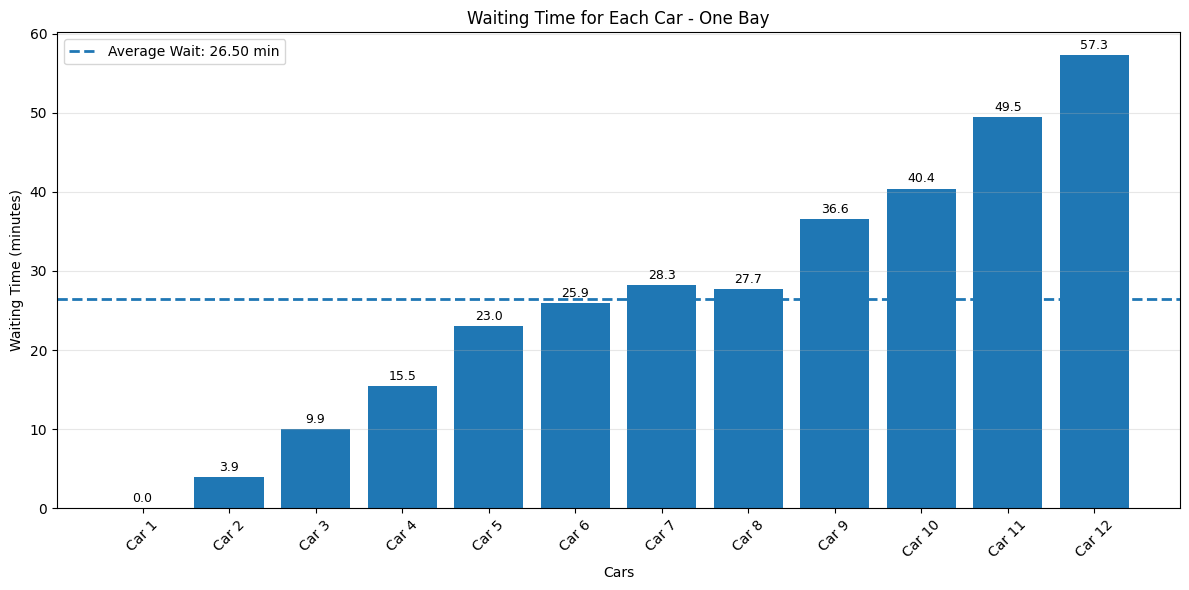

In [ ]:
# ---------------------------------
# Waiting time chart - One Bay
# ---------------------------------

one_bay_data = (
    results_1bay
    .sort_values("car_id")
    .reset_index(drop=True)
)

average_wait_1bay = one_bay_data["waiting_time"].mean()

plt.figure(figsize=(12, 6))

bars = plt.bar(
    one_bay_data["car"],
    one_bay_data["waiting_time"]
)

# Average waiting time line
plt.axhline(
    y=average_wait_1bay,
    linestyle="--",
    linewidth=2,
    label=f"Average Wait: {average_wait_1bay:.2f} min"
)

# Display values above the bars
for bar, value in zip(
    bars,
    one_bay_data["waiting_time"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Waiting Time for Each Car - One Bay")
plt.xlabel("Cars")
plt.ylabel("Waiting Time (minutes)")

plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

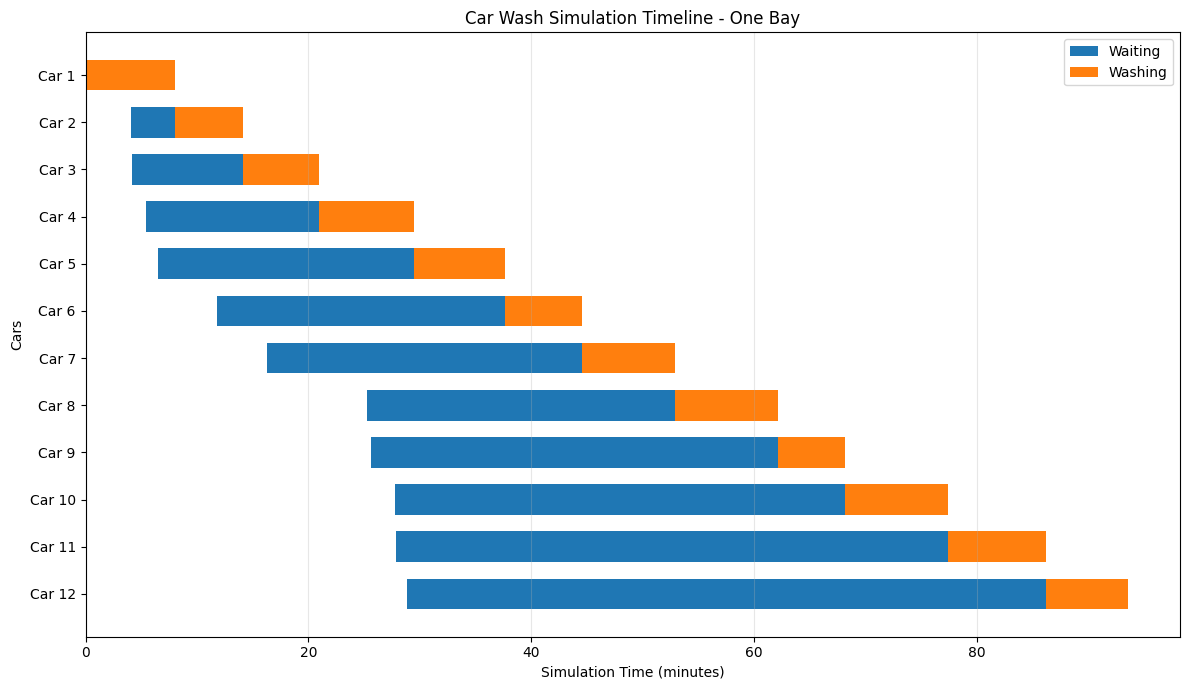

In [ ]:
# ---------------------------------
# Timeline chart - One Bay
# ---------------------------------

plt.figure(figsize=(12, 7))

plt.barh(
    one_bay_data["car"],
    one_bay_data["waiting_time"],
    left=one_bay_data["arrival_time"],
    height=0.65,
    label="Waiting"
)

plt.barh(
    one_bay_data["car"],
    one_bay_data["wash_time"],
    left=one_bay_data["start_time"],
    height=0.65,
    label="Washing"
)

plt.title("Car Wash Simulation Timeline - One Bay")
plt.xlabel("Simulation Time (minutes)")
plt.ylabel("Cars")

plt.legend()
plt.grid(axis="x", alpha=0.3)

# Show Car 1 at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------
# Scenario 2: Two washing bays
# ---------------------------------

results_2bays, summary_2bays = run_carwash(
    num_bays=2,
    input_data=input_data,
    verbose=True
)

Car 1 arrived at minute 0.00
Car 1 started washing at minute 0.00 after waiting 0.00 minutes
Car 2 arrived at minute 4.08
Car 2 started washing at minute 4.08 after waiting 0.00 minutes
Car 3 arrived at minute 4.18
Car 4 arrived at minute 5.47
Car 5 arrived at minute 6.48
Car 1 finished washing at minute 8.02
Car 3 started washing at minute 8.02 after waiting 3.84 minutes
Car 2 finished washing at minute 10.19
Car 4 started washing at minute 10.19 after waiting 4.72 minutes
Car 6 arrived at minute 11.81
Car 3 finished washing at minute 14.82
Car 5 started washing at minute 14.82 after waiting 8.34 minutes
Car 7 arrived at minute 16.33
Car 4 finished washing at minute 18.79
Car 6 started washing at minute 18.79 after waiting 6.97 minutes
Car 5 finished washing at minute 23.00
Car 7 started washing at minute 23.00 after waiting 6.67 minutes
Car 8 arrived at minute 25.24
Car 9 arrived at minute 25.60
Car 6 finished washing at minute 25.67
Car 8 started washing at minute 25.67 after waitin

In [ ]:
# ---------------------------------
# Detailed results - Two Bays
# ---------------------------------

print("Detailed Results - Two Bays Scenario:")

display(
    results_2bays.round(2)
)

Detailed Results - Two Bays Scenario:


,car_id,car,arrival_time,start_time,waiting_time,wash_time,finish_time,total_time
0,1,Car 1,0.00,0.00,0.00,8.02,8.02,8.02
1,2,Car 2,4.08,4.08,0.00,6.11,10.19,6.11
2,3,Car 3,4.18,8.02,3.84,6.80,14.82,10.64
3,4,Car 4,5.47,10.19,4.72,8.60,18.79,13.32
4,5,Car 5,6.48,14.82,8.34,8.18,23.00,16.52
5,6,Car 6,11.81,18.79,6.97,6.88,25.67,13.85
6,7,Car 7,16.33,23.00,6.67,8.36,31.35,15.02
7,8,Car 8,25.24,25.67,0.43,9.24,34.91,9.67
8,9,Car 9,25.60,31.35,5.75,6.03,37.38,11.78
9,10,Car 10,27.79,34.91,7.11,9.22,44.13,16.33


In [ ]:
# ---------------------------------
# Compare both scenarios
# ---------------------------------

comparison_table = pd.DataFrame([
    summary_1bay,
    summary_2bays
])

print("Final Scenario Comparison:")

display(
    comparison_table.round(2)
)

Final Scenario Comparison:


,Scenario,Number of Bays,Cars Served,Average Wait (min),Maximum Wait (min),Average Total Time (min),Simulation End (min),Utilization (%)
0,1 Bay,1,12,26.50,57.32,34.30,93.58,100.00
1,2 Bays,2,12,5.71,15.23,13.51,51.49,90.87


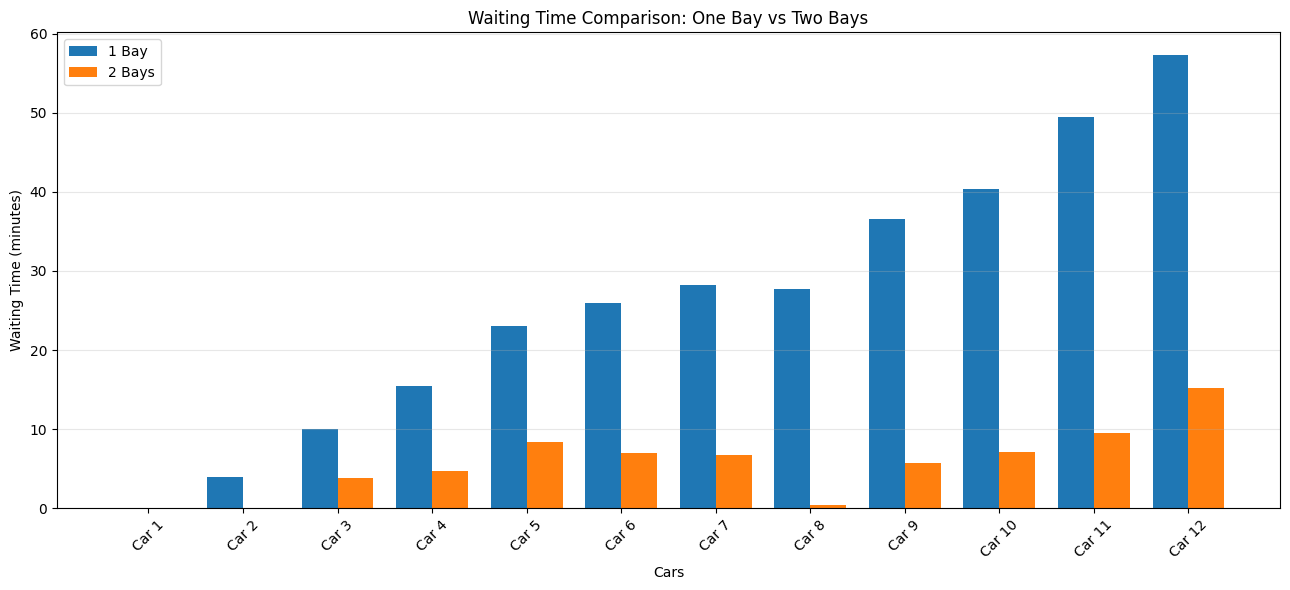

In [ ]:
# ---------------------------------
# Waiting time comparison chart
# ---------------------------------

comparison_data = pd.DataFrame({
    "car": results_1bay["car"],
    "one_bay_wait": results_1bay["waiting_time"],
    "two_bays_wait": results_2bays["waiting_time"]
})

x_positions = list(range(len(comparison_data)))
bar_width = 0.38

plt.figure(figsize=(13, 6))

bars_one = plt.bar(
    [x - bar_width / 2 for x in x_positions],
    comparison_data["one_bay_wait"],
    width=bar_width,
    label="1 Bay"
)

bars_two = plt.bar(
    [x + bar_width / 2 for x in x_positions],
    comparison_data["two_bays_wait"],
    width=bar_width,
    label="2 Bays"
)

plt.title("Waiting Time Comparison: One Bay vs Two Bays")
plt.xlabel("Cars")
plt.ylabel("Waiting Time (minutes)")

plt.xticks(
    x_positions,
    comparison_data["car"],
    rotation=45
)

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

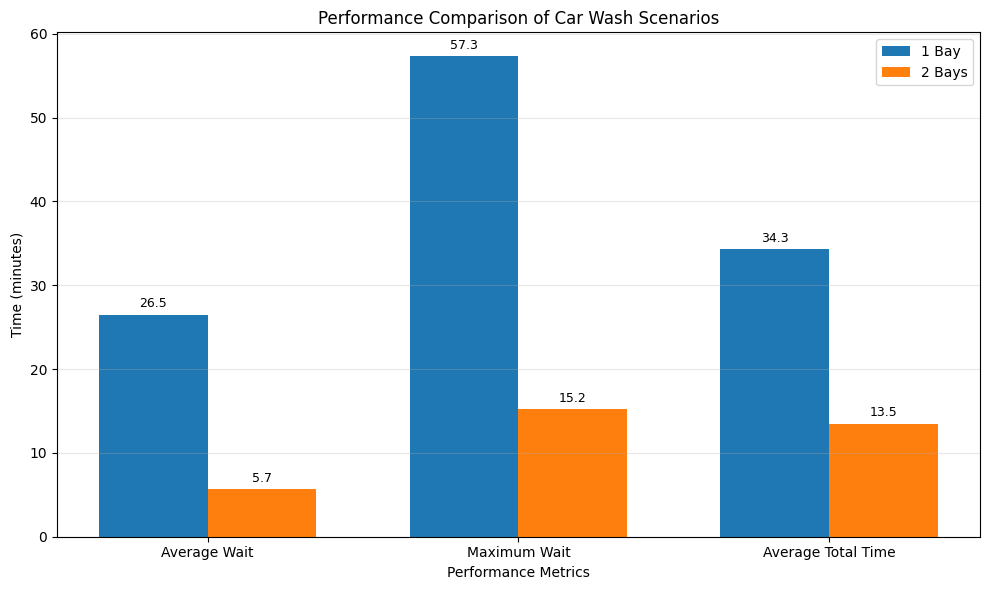

In [ ]:
# ---------------------------------
# Main performance metrics chart
# ---------------------------------

metrics = [
    "Average Wait",
    "Maximum Wait",
    "Average Total Time"
]

one_bay_values = [
    summary_1bay["Average Wait (min)"],
    summary_1bay["Maximum Wait (min)"],
    summary_1bay["Average Total Time (min)"]
]

two_bays_values = [
    summary_2bays["Average Wait (min)"],
    summary_2bays["Maximum Wait (min)"],
    summary_2bays["Average Total Time (min)"]
]

x_positions = list(range(len(metrics)))
bar_width = 0.35

plt.figure(figsize=(10, 6))

bars_one = plt.bar(
    [x - bar_width / 2 for x in x_positions],
    one_bay_values,
    width=bar_width,
    label="1 Bay"
)

bars_two = plt.bar(
    [x + bar_width / 2 for x in x_positions],
    two_bays_values,
    width=bar_width,
    label="2 Bays"
)

# Display values above the bars
for bars in [bars_one, bars_two]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.5,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.title("Performance Comparison of Car Wash Scenarios")
plt.xlabel("Performance Metrics")
plt.ylabel("Time (minutes)")

plt.xticks(
    x_positions,
    metrics
)

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
# ---------------------------------
# Calculate improvement percentages
# ---------------------------------

average_wait_1 = summary_1bay["Average Wait (min)"]
average_wait_2 = summary_2bays["Average Wait (min)"]

maximum_wait_1 = summary_1bay["Maximum Wait (min)"]
maximum_wait_2 = summary_2bays["Maximum Wait (min)"]

total_time_1 = summary_1bay["Average Total Time (min)"]
total_time_2 = summary_2bays["Average Total Time (min)"]

average_wait_reduction = (
    (average_wait_1 - average_wait_2)
    / average_wait_1
) * 100 if average_wait_1 > 0 else 0

maximum_wait_reduction = (
    (maximum_wait_1 - maximum_wait_2)
    / maximum_wait_1
) * 100 if maximum_wait_1 > 0 else 0

total_time_reduction = (
    (total_time_1 - total_time_2)
    / total_time_1
) * 100 if total_time_1 > 0 else 0

print("----- Improvement After Adding the Second Bay -----")

print(
    f"Average waiting time reduction: "
    f"{average_wait_reduction:.2f}%"
)

print(
    f"Maximum waiting time reduction: "
    f"{maximum_wait_reduction:.2f}%"
)

print(
    f"Average total time reduction: "
    f"{total_time_reduction:.2f}%"
)

----- Improvement After Adding the Second Bay -----
Average waiting time reduction: 78.46%
Maximum waiting time reduction: 73.44%
Average total time reduction: 60.62%
